In [3]:
!pip install rpy2
%load_ext rpy2.ipython

In [6]:
%%R
# =============================================================
# Practical: Air-Quality Data Cleaning Using R
# Dataset : Beijing Multi-Site Air Quality Dataset (Aotizhongxin station)
# =============================================================

# -------------------------------------------------------------
# TASK 1: Import and Inspect the Dataset
# -------------------------------------------------------------

import_dataset <- function(path) {
  tryCatch({
    data <- read.csv(path, stringsAsFactors = FALSE)
    cat("File imported successfully.\n")
    return(data)
  },
  error = function(e) {
    if (!file.exists(path)) {
      message("Error: The file was not found at the specified path.")
    } else {
      message("Error: The file could not be opened or is in an incorrect format.")
    }
    message("Details: ", conditionMessage(e))
    return(NULL)
  })
}

aq <- import_dataset("PRSA_Data_Aotizhongxin_20130301-20170228.csv")

cat("\n--- First six records ---\n")
print(head(aq))

cat("\n--- Structure of the dataset ---\n")
str(aq)

cat("\n--- Rows and Columns ---\n")
cat("Rows:", nrow(aq), " Columns:", ncol(aq), "\n")

cat("\n--- Does the dataset contain missing values? ---\n")
print(any(is.na(aq)))

cat("\n--- Total number of missing values ---\n")
print(sum(is.na(aq)))


# -------------------------------------------------------------
# TASK 2: Understand NA, NULL, and NaN
# -------------------------------------------------------------

temperature   <- c(28, 30, NA, 32)
missing_object <- NULL
undefined_value <- 0 / 0

cat("\n--- NA example ---\n")
print(temperature)
cat("is.na():", is.na(temperature), "\n")

cat("\n--- NULL example ---\n")
print(missing_object)
cat("is.null():", is.null(missing_object), "\n")

cat("\n--- NaN example ---\n")
print(undefined_value)
cat("is.nan():", is.nan(undefined_value), "\n")


# -------------------------------------------------------------
# TASK 3: Missing-Value Summary Function
# -------------------------------------------------------------

missing_summary <- function(df) {
  vars <- names(df)
  total <- nrow(df)
  result <- data.frame(
    Variable = character(),
    Total_Records = integer(),
    Missing_Values = integer(),
    Missing_Percentage = numeric(),
    stringsAsFactors = FALSE
  )

  for (v in vars) {
    missing_count <- sum(is.na(df[[v]]))
    missing_pct <- round((missing_count / total) * 100, 2)

    if (missing_pct > 20) {
      warning(paste0("Variable '", v, "' has more than 20% missing values (",
                      missing_pct, "%)."))
    }

    result <- rbind(result, data.frame(
      Variable = v,
      Total_Records = total,
      Missing_Values = missing_count,
      Missing_Percentage = missing_pct
    ))
  }
  return(result)
}

selected_vars <- c("PM2.5", "PM10", "SO2", "NO2", "TEMP", "WSPM", "wd")
summary_table <- missing_summary(aq[selected_vars])

cat("\n--- Missing-Value Summary ---\n")
print(summary_table)


# -------------------------------------------------------------
# TASK 4: Identify Invalid Numerical Results
# -------------------------------------------------------------

aq$pollution_ratio <- aq$PM2.5 / aq$PM10

cat("\n--- pollution_ratio diagnostics (before cleaning) ---\n")
cat("NA count:      ", sum(is.na(aq$pollution_ratio)), "\n")
cat("NaN count:     ", sum(is.nan(aq$pollution_ratio)), "\n")
cat("+Inf count:    ", sum(aq$pollution_ratio == Inf, na.rm = TRUE), "\n")
cat("-Inf count:    ", sum(aq$pollution_ratio == -Inf, na.rm = TRUE), "\n")

aq$pollution_ratio[is.nan(aq$pollution_ratio) | is.infinite(aq$pollution_ratio)] <- NA

cat("\n--- pollution_ratio diagnostics (after replacing NaN/Inf with NA) ---\n")
cat("NA count:      ", sum(is.na(aq$pollution_ratio)), "\n")
cat("NaN count:     ", sum(is.nan(aq$pollution_ratio)), "\n")
cat("Infinite count:", sum(is.infinite(aq$pollution_ratio)), "\n")


# -------------------------------------------------------------
# TASK 5: Handle Missing Numerical Values Using a Loop
# -------------------------------------------------------------

numeric_variables <- c("PM2.5", "PM10", "SO2", "NO2", "TEMP", "WSPM")

# capture "before" counts for the comparison table (Task 8)
missing_before <- sapply(aq[c(numeric_variables, "wd")], function(x) sum(is.na(x)))

cat("\n--- Task 5: Median imputation loop ---\n")
for (var in numeric_variables) {

  if (!(var %in% names(aq))) {
    cat("Column", var, "does not exist. Skipping.\n")
    next
  }

  before_count <- sum(is.na(aq[[var]]))
  med_value <- median(aq[[var]], na.rm = TRUE)
  aq[[var]][is.na(aq[[var]])] <- med_value
  after_count <- sum(is.na(aq[[var]]))

  cat(sprintf("Variable: %-6s | Missing before: %4d | Median used: %8.2f | Missing after: %d\n",
              var, before_count, med_value, after_count))
}


# -------------------------------------------------------------
# TASK 6: Handle Missing Categorical Values
# -------------------------------------------------------------

calculate_mode <- function(x) {
  x <- x[!is.na(x)]
  freq_table <- table(x)
  mode_value <- names(freq_table)[which.max(freq_table)]
  return(mode_value)
}

wd_before <- sum(is.na(aq$wd))
wd_mode <- calculate_mode(aq$wd)
aq$wd[is.na(aq$wd)] <- wd_mode
wd_after <- sum(is.na(aq$wd))

cat("\n--- Task 6: Categorical imputation (wd) ---\n")
cat("Mode of wd:", wd_mode, "\n")
cat("Missing before:", wd_before, " | Missing after:", wd_after, "\n")


# -------------------------------------------------------------
# TASK 7: Implement Error Handling (clean_variable)
# -------------------------------------------------------------

clean_variable <- function(df, var_name) {
  tryCatch({
    if (!(var_name %in% names(df))) {
      stop(paste0("Variable '", var_name, "' does not exist in the dataset."))
    }

    variable <- df[[var_name]]

    if (!is.numeric(variable)) {
      stop(paste0("Variable '", var_name, "' is categorical, not numerical."))
    }

    if (all(is.na(variable))) {
      stop(paste0("Variable '", var_name, "' contains only missing values."))
    }

    med_value <- median(variable, na.rm = TRUE)

    if (is.na(med_value)) {
      stop(paste0("Median could not be calculated for '", var_name, "'."))
    }

    variable[is.na(variable)] <- med_value
    return(variable)
  },
  error = function(e) {
    message("clean_variable() could not process '", var_name, "': ", conditionMessage(e))
    return(df[[var_name]])
  })
}

cat("\n--- Task 7: clean_variable() demonstration ---\n")
test1 <- clean_variable(aq, "SO2")             # valid numeric variable
test2 <- clean_variable(aq, "wd")              # categorical variable -> handled error
test3 <- clean_variable(aq, "NotAColumn")      # non-existent variable -> handled error


# -------------------------------------------------------------
# TASK 8: Compare Missing Values Before and After Cleaning
# -------------------------------------------------------------

compare_vars <- c(numeric_variables, "wd")
missing_after <- sapply(aq[compare_vars], function(x) sum(is.na(x)))

comparison_table <- data.frame(
  Variable = compare_vars,
  Missing_Before = as.integer(missing_before[compare_vars]),
  Missing_After = as.integer(missing_after[compare_vars]),
  Values_Replaced = as.integer(missing_before[compare_vars]) - as.integer(missing_after[compare_vars])
)

cat("\n--- Task 8: Comparison Table ---\n")
print(comparison_table)

all_handled <- all(comparison_table$Missing_After == 0)
cat("\nAll selected missing values handled successfully:", all_handled, "\n")


# -------------------------------------------------------------
# TASK 9: Generate One Visualization
# -------------------------------------------------------------

png("missing_values_comparison.png", width = 900, height = 600, res = 120)

bar_data <- t(as.matrix(comparison_table[, c("Missing_Before", "Missing_After")]))
colnames(bar_data) <- comparison_table$Variable

barplot(bar_data,
        beside = TRUE,
        col = c("firebrick", "forestgreen"),
        main = "Missing Values Before vs After Data Cleaning",
        xlab = "Variable",
        ylab = "Number of Missing Values",
        legend.text = c("Before Cleaning", "After Cleaning"),
        args.legend = list(x = "topright"))

dev.off()
cat("\nVisualization saved as missing_values_comparison.png\n")


# -------------------------------------------------------------
# TASK 10: Export the Cleaned Dataset
# -------------------------------------------------------------

write.csv(aq, "cleaned_air_quality_data.csv", row.names = FALSE)
cat("\nCleaned dataset exported as cleaned_air_quality_data.csv\n")

# Save the summary/comparison tables so they can be pulled into the report
write.csv(summary_table, "missing_summary_table.csv", row.names = FALSE)
write.csv(comparison_table, "comparison_table.csv", row.names = FALSE)

cat("\n=== SCRIPT COMPLETE ===\n")

File imported successfully.

--- First six records ---
  No year month day hour PM2.5 PM10 SO2 NO2  CO O3 TEMP   PRES  DEWP RAIN  wd
1  1 2013     3   1    0     4    4   4   7 300 77 -0.7 1023.0 -18.8    0 NNW
2  2 2013     3   1    1     8    8   4   7 300 77 -1.1 1023.2 -18.2    0   N
3  3 2013     3   1    2     7    7   5  10 300 73 -1.1 1023.5 -18.2    0 NNW
4  4 2013     3   1    3     6    6  11  11 300 72 -1.4 1024.5 -19.4    0  NW
5  5 2013     3   1    4     3    3  12  12 300 72 -2.0 1025.2 -19.5    0   N
6  6 2013     3   1    5     5    5  18  18 400 66 -2.2 1025.6 -19.6    0   N
  WSPM      station
1  4.4 Aotizhongxin
2  4.7 Aotizhongxin
3  5.6 Aotizhongxin
4  3.1 Aotizhongxin
5  2.0 Aotizhongxin
6  3.7 Aotizhongxin

--- Structure of the dataset ---
'data.frame':	35064 obs. of  18 variables:
 $ No     : int  1 2 3 4 5 6 7 8 9 10 ...
 $ year   : int  2013 2013 2013 2013 2013 2013 2013 2013 2013 2013 ...
 $ month  : int  3 3 3 3 3 3 3 3 3 3 ...
 $ day    : int  1 1 1 1 1 1

clean_variable() could not process 'wd': Variable 'wd' is categorical, not numerical.
clean_variable() could not process 'NotAColumn': Variable 'NotAColumn' does not exist in the dataset.


### Task 9

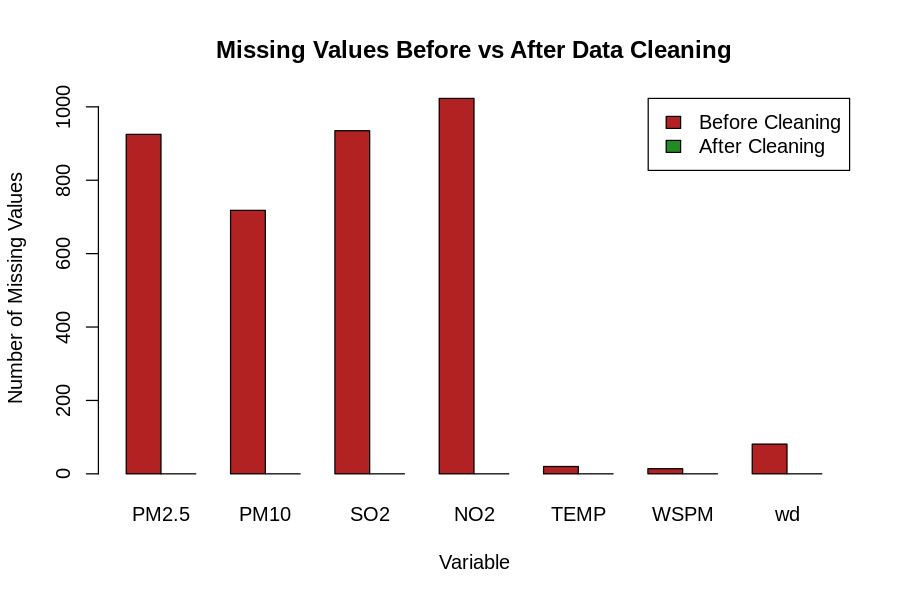

In [7]:
from IPython.display import Image

# Display the saved PNG image
Image('missing_values_comparison.png')